In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# 🎯 Purporse project

* ### 1. Add Dataframe (df) features to ensure the LLM prompting is relevant to dataframe

* ### 2. Integration PDF report to dataframe for as reliable chatbot

* ### 3. Match recommendation system toward the images for where the product will be shown in UI as ranking recommendation

* ### 4. Merge LSTM model for sales and profit_status prediction (Optional)

* ### 5. Build chatbot experiment integration

## Load images dataset

In [2]:
from PIL import Image

IMAGE_DIR = "../../../fashion_images/dataset_clean"

images = []
image_paths = []

# iterate to call images data
for root, _, files in os.walk(IMAGE_DIR):
    for filename in files:
        if filename.lower().endswith(".jpg"):
            path = os.path.join(root, filename)
            image = Image.open(path).convert("RGB")
            images.append(image)
            image_paths.append(path)
    
print(f"Loaded {len(images)} JPG Images")

Loaded 8625 JPG Images


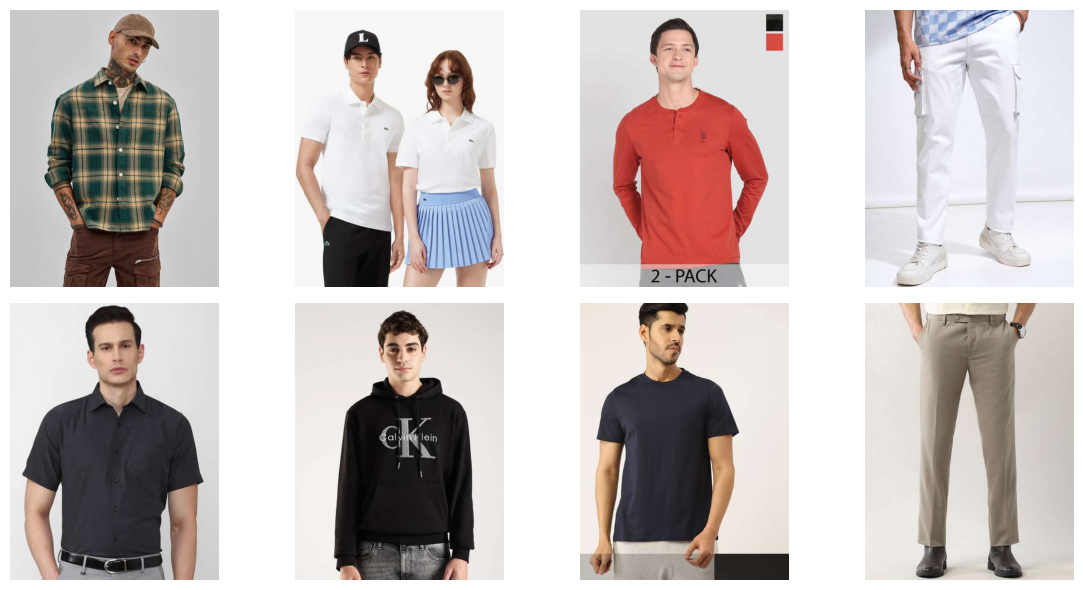

In [3]:
# Show random images

import random
import matplotlib.pyplot as plt

def show_random_images(images, n=8, cols=4, figsize=(12, 6)):
    n = min(n, len(images))
    selected = random.sample(images, n)

    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)

    for i, img in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Usage
show_random_images(images, n=8)

## Load dataset

In [4]:
# Load parquet images dataset
df_images = pd.read_parquet("../../../data/matched_fashion_dataset.parquet")

# Load dataframes
df = pd.read_parquet("../../../MLOps/database/data/raw/matched_fashion_balance_rows_prediction.parquet")

## Feature engineering dataframes

* ### Define dir images for ensure the images is exists
* ### Attached df_images -> df (dataframe merged conceptual)

In [5]:
image_dir = "../../../fashion_images/dataset_clean"
from pathlib import Path

# Load data but don't as list
image_list = Path(image_dir).rglob("*.jpg")
image_list = list(image_list)  # Convert generator to list for indexing
image_list[:5]

[PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg')]

In [6]:
image_paths_label = [
    {
       "image_path" : str(p).replace("../../../", ""),
        "filename"   : p.name,
        "category"   : p.parent.name
    }
    for p in image_list
]

image_paths_label[:5]

[{'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0969.jpg',
  'filename': 'img_0969.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0955.jpg',
  'filename': 'img_0955.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0799.jpg',
  'filename': 'img_0799.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0941.jpg',
  'filename': 'img_0941.jpg',
  'category': 'formal_shirts'},
 {'image_path': 'fashion_images/dataset_clean/formal_shirts/img_0772.jpg',
  'filename': 'img_0772.jpg',
  'category': 'formal_shirts'}]

In [7]:
from pathlib import Path

# Define images_path based on category folders in image_paths

for item in image_paths[:10]:
    item_fashion = str(Path(item).name)
    item_class = str(Path(item).parent.name)
    print(item_fashion, item_class)

img_0969.jpg formal_shirts
img_0955.jpg formal_shirts
img_0799.jpg formal_shirts
img_0941.jpg formal_shirts
img_0772.jpg formal_shirts
img_0014.jpg formal_shirts
img_0766.jpg formal_shirts
img_0996.jpg formal_shirts
img_0028.jpg formal_shirts
img_0982.jpg formal_shirts


In [8]:
df_images

,item_id,category,subcategory,sleeve_type,season,fabric,occasion,formality_level,size_range,brand,view_count,click_count,purchase_count,length_cm,price,stocks,item_id_str,idx_within_subcat,image_path
0,TNC_000001,bottoms,men_cargos,long,winter,polyester,casual,high,S,Tommy Hilfiger,93,192,4,97,262476,35,TNC_000001,0,../fashion_images/dataset_clean/men_cargos/img...
1,TNC_000002,tops,formal_shirts,long,winter,linen,party,medium,S,HnM,2941,84,5,77,266987,182,TNC_000002,0,../fashion_images/dataset_clean/formal_shirts/...
2,TNC_000003,tops,formal_shirts,long,winter,denim,party,high,XL,HnM,401,434,35,71,286065,32,TNC_000003,1,../fashion_images/dataset_clean/formal_shirts/...
3,TNC_000004,tops,printed_tshirts,short,all-season,linen,office,low,XXL,Tommy Hilfiger,318,85,101,70,153376,149,TNC_000004,0,../fashion_images/dataset_clean/printed_tshirt...
4,TNC_000005,tops,formal_shirts,long,all-season,polyester,casual,low,L,ZARA,857,153,67,69,323155,43,TNC_000005,2,../fashion_images/dataset_clean/formal_shirts/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099995,TNC_1099996,tops,solid_tshirts,short,summer,polyester,party,medium,M,HnM,2924,183,2,73,140786,163,TNC_1099996,109772,../fashion_images/dataset_clean/solid_tshirts/...
1099996,TNC_1099997,bottoms,formal_pants,long,summer,denim,party,high,XXL,Polo,2362,94,32,95,353863,198,TNC_1099997,183895,../fashion_images/dataset_clean/formal_pants/i...
1099997,TNC_1099998,bottoms,men_cargos,long,winter,fleece,casual,low,M,Adidas,617,147,39,97,299627,78,TNC_1099998,183289,../fashion_images/dataset_clean/men_cargos/img...
1099998,TNC_1099999,tops,solid_tshirts,short,summer,cotton,office,low,XXL,Tommy Hilfiger,326,0,25,71,153123,172,TNC_1099999,109773,../fashion_images/dataset_clean/solid_tshirts/...


In [9]:
image_paths_df_images = df_images['image_path'].iloc[:len(df)].reset_index(drop=True) # Define image_paths here before attaching to df
subcategory_paths_df_images = df_images['subcategory'].iloc[:len(df)].reset_index(drop=True) # Define subcategory_paths here before attaching to df
category_paths_df_images = df_images['category'].iloc[:len(df)].reset_index(drop=True) # Define category_paths here before attaching to df
brand_paths_df_images = df_images['brand'].iloc[:len(df)].reset_index(drop=True) # Define brand_paths here before attaching to df
occasion_paths_df_images = df_images['occasion'].iloc[:len(df)].reset_index(drop=True) # Define occasion_paths here before attaching to df
size_range_paths_df_images = df_images['size_range'].iloc[:len(df)].reset_index(drop=True) # Define size_range_paths here before attaching to df

# Attach to df
df_merged = df.copy()
df_merged['image_path'] = image_paths_df_images
df_merged['subcategory'] = subcategory_paths_df_images
df_merged['category'] = category_paths_df_images
df_merged['brand'] = brand_paths_df_images
df_merged['occasion'] = occasion_paths_df_images
df_merged['size_range'] = size_range_paths_df_images

print(f"Merged shape:         {df_merged.shape}")          # 298,150
print(f"Missing image_path:   {df_merged['image_path'].isna().sum()}")  # should be 0
print(df_merged[['item_id', 'image_path']].head())

Merged shape:         (298150, 19)
Missing image_path:   0
       item_id                                         image_path
0  item_000001  ../fashion_images/dataset_clean/men_cargos/img...
1  item_000001  ../fashion_images/dataset_clean/formal_shirts/...
2  item_000001  ../fashion_images/dataset_clean/formal_shirts/...
3  item_000001  ../fashion_images/dataset_clean/printed_tshirt...
4  item_000001  ../fashion_images/dataset_clean/formal_shirts/...


In [10]:
# Fix paths for diplay on df_merged
df_merged['image_path'] = list(df_merged['image_path'].apply(lambda x: str(x).replace("../", "../../../")))
df_merged.head()

,item_id,date,purchase_count,view_count,price,stocks,sales,stock_value_retail,profit_status,conversion_rate,sales_log,predicted_sales,predicted_profit,image_path,subcategory,category,brand,occasion,size_range
0,item_000001,2025-01-31,3.0,3736.0,346555.0,172.0,30383339.0,49100152.0,1.0,60.195342,17.229404,127866.250000,profit,../../../fashion_images/dataset_clean/men_carg...,men_cargos,bottoms,Tommy Hilfiger,casual,S
1,item_000001,2025-02-01,3.0,356.0,216545.0,96.0,24742335.0,25600992.0,1.0,70.376131,17.024027,56849.851562,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,HnM,party,S
2,item_000001,2025-02-02,0.0,0.0,216545.0,96.0,0.0,25600992.0,1.0,0.000000,0.000000,104502.617188,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,HnM,party,XL
3,item_000001,2025-02-03,2.0,1044.0,284314.0,49.0,17303367.0,14108619.0,1.0,6.638782,16.666412,32212.800781,profit,../../../fashion_images/dataset_clean/printed_...,printed_tshirts,tops,Tommy Hilfiger,office,XXL
4,item_000001,2025-02-04,2.0,1104.0,285865.0,148.0,18683496.0,41282232.0,1.0,6.484313,16.743151,75313.539062,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,ZARA,casual,L


In [11]:
image_paths[:10]

['../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0014.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0766.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0996.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0028.jpg',
 '../../../fashion_images/dataset_clean/formal_shirts/img_0982.jpg']

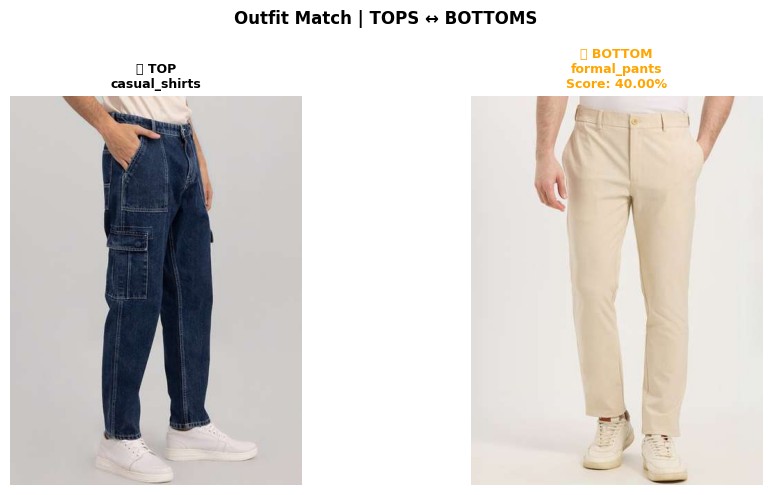

Input    : ../../../fashion_images/dataset_clean/jeans/img_0142.jpg
Matched  : ../../../fashion_images/dataset_clean/formal_pants/img_0969.jpg
Score    : 40.00%


In [12]:
from difflib import SequenceMatcher
import os
import random

# Buikd fast lookup: filename -> (Category, Subcategory, Full Path)
lookup = {
    Path(str(r['image_path'])).name: r for _, r in df_merged.drop_duplicates(subset=['image_path']).iterrows()
}

def match_outfit(image_path, df_merged):
    input_name = Path(str(image_path)).name
    input_row = lookup.get(input_name)

    if input_row is None:
        print(f"Image {input_name} not found in dataset.")

    input_category = str(input_row['category']).lower()
    input_subcategory = str(input_row['subcategory']).lower()
    target_category = 'bottoms' if input_category == 'tops' else 'tops'

    # Filter opposite category & score
    df_opp = df_merged[df_merged['category'].str.lower() == target_category]
    df_opp = df_opp.assign(score=df_opp['subcategory'].apply(
        lambda s: SequenceMatcher(None, input_subcategory, str(s).lower()).ratio()
    ))
    best = df_opp.loc[df_opp['score'].idxmax()]
    percentage = best['score'] * 100

    # Display
    color = 'green' if percentage > 70 else 'orange' if percentage >= 40 else 'red'
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(Image.open(image_path));         axes[0].axis('off')
    axes[0].set_title(f"{'👕 TOP' if input_category=='tops' else '👖 BOTTOM'}\n{input_subcategory}", fontsize=9, fontweight='bold')
    axes[1].imshow(Image.open(best['image_path'])); axes[1].axis('off')
    axes[1].set_title(f"{'👖 BOTTOM' if input_category=='tops' else '👕 TOP'}\n{best['subcategory']}\nScore: {percentage:.2f}%", fontsize=9, color=color, fontweight='bold')
    plt.suptitle(f"Outfit Match | {input_category.upper()} ↔ {target_category.upper()}", fontweight='bold')
    plt.tight_layout(); plt.show()

    return best, best['score']

# Example usage
PATH_IMAGES = Path("../../../fashion_images/dataset_clean")
test_image_path = str(random.choice(list(PATH_IMAGES.rglob("*.jpg"))))

best, score = match_outfit(test_image_path, df_merged)
print(f"Input    : {test_image_path}")
print(f"Matched  : {best['image_path']}")
print(f"Score    : {score * 100:.2f}%")

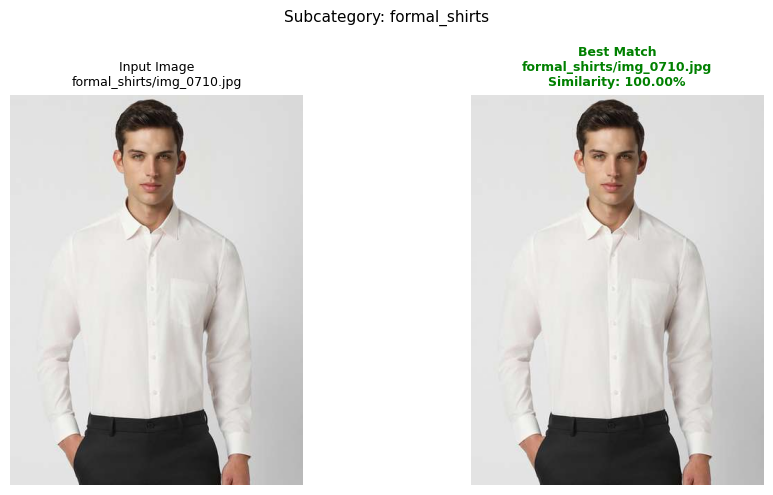

Input      : ../../../fashion_images/dataset_clean/formal_shirts/img_0710.jpg
Best match : ../../../fashion_images/dataset_clean/formal_shirts/img_0710.jpg
Subcategory: formal_shirts
Similarity : 100.00%


In [13]:
from difflib import SequenceMatcher
from pathlib import Path
import os, random

def image_path_similarity(image_path, df_merged):
    """Match input image against df_merged using FULL path (folder + filename)"""
    best_match    = None
    highest_ratio = 0

    input_path   = str(image_path)
    input_folder = Path(image_path).parent.name   # e.g. 'formal_shirts'
    input_name   = Path(image_path).name           # e.g. 'img_1169.jpg'

    for _, row in df_merged.iterrows():
        df_path   = str(row['image_path'])
        df_folder = Path(df_path).parent.name      # e.g. 'formal_shirts'
        df_name   = Path(df_path).name             # e.g. 'img_1169.jpg'

        # ── Match: folder (subcategory) + filename BOTH must align ──
        ratio_folder = SequenceMatcher(None, input_folder, df_folder).ratio()
        ratio_name   = SequenceMatcher(None, input_name,   df_name).ratio()

        # Weight folder match higher to avoid cross-category false positives
        weighted = (ratio_folder * 0.7) + (ratio_name * 0.3)

        if weighted > highest_ratio:
            highest_ratio = weighted
            best_match    = row

    # ── Display ───────────────────────────────────────────────
    if best_match is not None:
        score = highest_ratio * 100
        color = 'green' if score >= 70 else 'orange' if score >= 40 else 'red'

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(Image.open(image_path))
        axes[0].set_title(
            f"Input Image\n{input_folder}/{input_name}",
            fontsize=9
        )
        axes[0].axis('off')

        axes[1].imshow(Image.open(best_match['image_path']))
        axes[1].set_title(
            f"Best Match\n{Path(best_match['image_path']).parent.name}/{Path(best_match['image_path']).name}\n"
            f"Similarity: {score:.2f}%",
            fontsize=9, color=color, fontweight='bold'
        )
        axes[1].axis('off')

        plt.suptitle(f"Subcategory: {best_match['subcategory']}", fontsize=11)
        plt.tight_layout()
        plt.show()

    return best_match, highest_ratio


# ── Example usage ─────────────────────────────────────────────
PATH_IMAGES     = Path("../../../fashion_images/dataset_clean")
test_image_path = str(random.choice(list(PATH_IMAGES.rglob("*.jpg"))))

best_match, similarity = image_path_similarity(test_image_path, df_merged)
print(f"Input      : {test_image_path}")
print(f"Best match : {best_match['image_path']}")
print(f"Subcategory: {best_match['subcategory']}")
print(f"Similarity : {similarity * 100:.2f}%")

## Top recommendation for matching outfit

Input: ../../../fashion_images/dataset_clean/jeans/img_0178.jpg



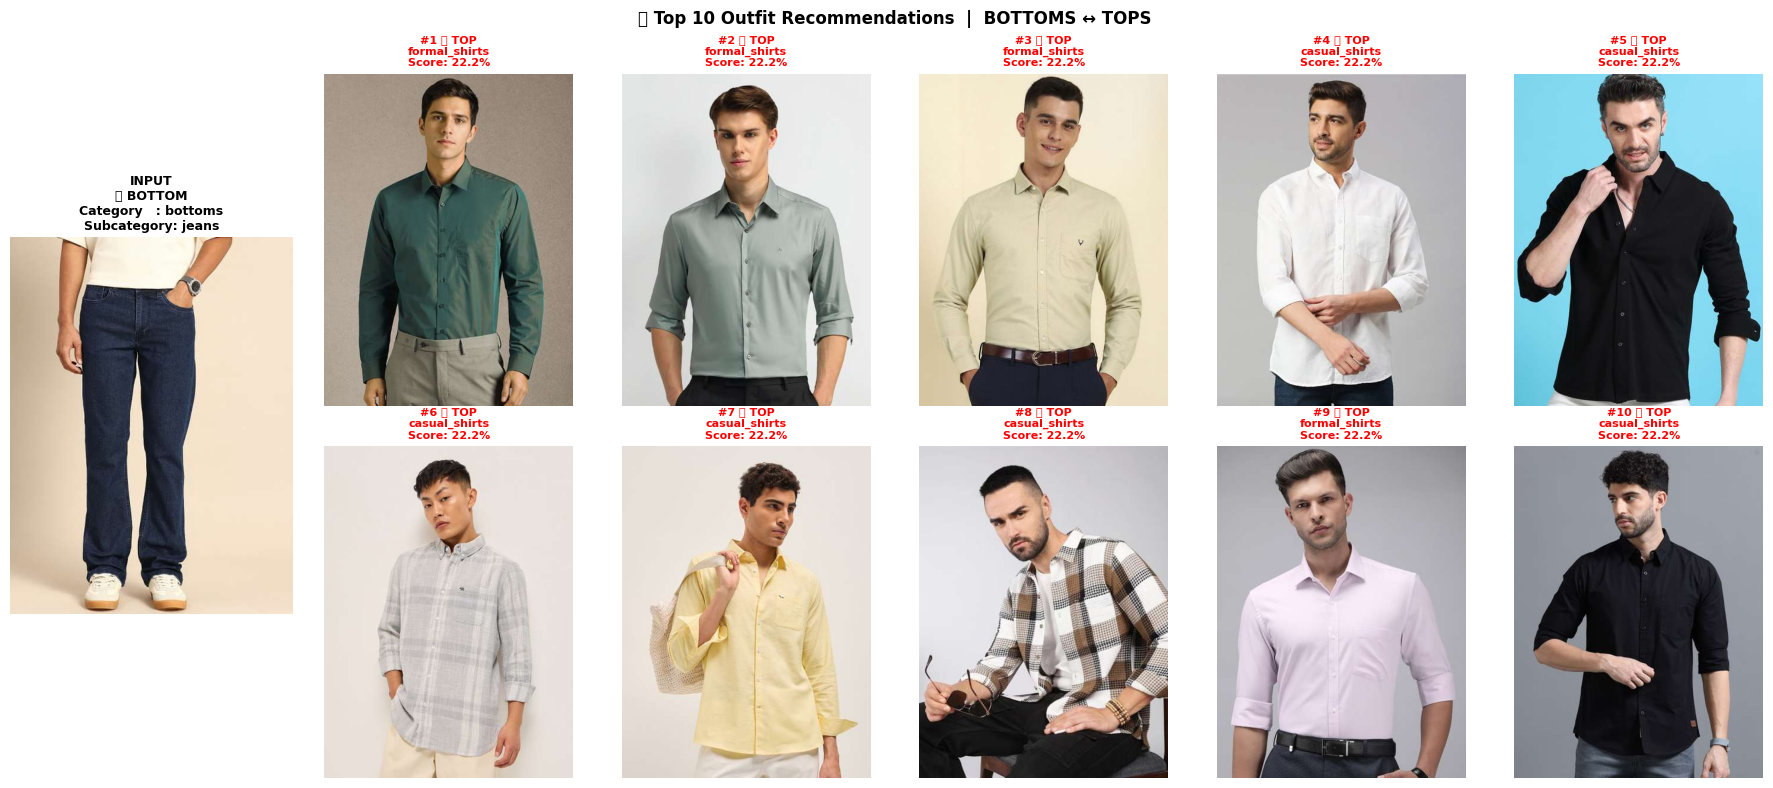


Input       : img_0178.jpg
Category    : bottoms  →  Recommending: tops
Subcategory : jeans
#1  formal_shirts             Score: 22.2%  |  img_0969.jpg
#2  formal_shirts             Score: 22.2%  |  img_0955.jpg
#3  formal_shirts             Score: 22.2%  |  img_0799.jpg
#4  casual_shirts             Score: 22.2%  |  img_0969.jpg
#5  casual_shirts             Score: 22.2%  |  img_0955.jpg
#6  casual_shirts             Score: 22.2%  |  img_0799.jpg
#7  casual_shirts             Score: 22.2%  |  img_0941.jpg
#8  casual_shirts             Score: 22.2%  |  img_0772.jpg
#9  formal_shirts             Score: 22.2%  |  img_0941.jpg
#10 casual_shirts             Score: 22.2%  |  img_0014.jpg


In [14]:
from difflib import SequenceMatcher
from pathlib import Path
import random

# ── Build lookup: (folder/filename) → row ────────────────────
lookup = {
    f"{Path(str(r['image_path'])).parent.name}/{Path(str(r['image_path'])).name}": r
    for _, r in df_merged.drop_duplicates('image_path').iterrows()
}

def recommend_outfit(image_path, df_merged, top_n=10):
    image_path = Path(str(image_path))
    input_key  = f"{image_path.parent.name}/{image_path.name}"
    input_row  = lookup.get(input_key)

    if input_row is None:
        print(f"⚠️ Not found in lookup: {input_key}"); return
    if not image_path.exists():
        print(f"⚠️ File not found on disk: {image_path}"); return

    input_cat    = str(input_row['category']).lower()
    input_subcat = str(input_row['subcategory']).lower()
    target_cat   = 'bottoms' if input_cat == 'tops' else 'tops'

    # ── Score opposite category ───────────────────────────────
    df_opp = df_merged[df_merged['category'].str.lower() == target_cat].copy()
    df_opp = df_opp.drop_duplicates('image_path')
    df_opp['score'] = df_opp['subcategory'].apply(
        lambda s: SequenceMatcher(None, input_subcat, str(s).lower()).ratio()
    )
    df_opp  = df_opp[df_opp['image_path'].apply(lambda p: Path(str(p)).exists())]
    top_rec = df_opp.nlargest(top_n, 'score')

    # ── Dynamic grid: 1 input col + ceil(top_n/rows) cols ────
    n_cols  = 6                              # 1 input + 5 recommendations per row
    n_rows  = -(-top_n // (n_cols - 1))     # ceil division  → 2 rows for top_n=10
    fig     = plt.figure(figsize=(n_cols * 3, n_rows * 4))

    # ── Input image spans all rows on the left ────────────────
    ax_input = fig.add_subplot(n_rows, n_cols, tuple(
        range(1, n_rows * n_cols, n_cols)   # e.g. [1, 7] for 2 rows
    ) if n_rows > 1 else 1)
    ax_input.imshow(Image.open(image_path))
    ax_input.axis('off')
    ax_input.set_title(
        f"INPUT\n{'👕 TOP' if input_cat == 'tops' else '👖 BOTTOM'}\n"
        f"Category   : {input_cat}\n"
        f"Subcategory: {input_subcat}",
        fontsize=9, fontweight='bold'
    )

    # ── Recommendation positions: skip col 1 every row ───────
    positions = [
        r * n_cols + c
        for r in range(n_rows)
        for c in range(2, n_cols + 1)       # cols 2–6
    ][:top_n]

    for i, (_, row) in enumerate(top_rec.iterrows()):
        pct   = row['score'] * 100
        color = 'green' if pct >= 70 else 'orange' if pct >= 40 else 'red'
        ax    = fig.add_subplot(n_rows, n_cols, positions[i])
        ax.imshow(Image.open(row['image_path']))
        ax.axis('off')
        ax.set_title(
            f"#{i+1} {'👖 BOTTOM' if input_cat == 'tops' else '👕 TOP'}\n"
            f"{row['subcategory']}\nScore: {pct:.1f}%",
            fontsize=8, color=color, fontweight='bold'
        )

    plt.suptitle(
        f"👗 Top {top_n} Outfit Recommendations  |  {input_cat.upper()} ↔ {target_cat.upper()}",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout(); plt.show()

    # ── Summary ───────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"Input       : {image_path.name}")
    print(f"Category    : {input_cat}  →  Recommending: {target_cat}")
    print(f"Subcategory : {input_subcat}")
    print(f"{'='*55}")
    for i, (_, row) in enumerate(top_rec.iterrows()):
        print(f"#{i+1:<2} {row['subcategory']:<25} Score: {row['score']*100:.1f}%  |  {Path(str(row['image_path'])).name}")

    return top_rec


# ── Usage ─────────────────────────────────────────────────────
INPUT_IMAGE = random.choice(list(PATH_IMAGES.rglob("*.jpg")))

print(f"Input: {INPUT_IMAGE}\n")
top_rec = recommend_outfit(INPUT_IMAGE, df_merged, top_n=10)

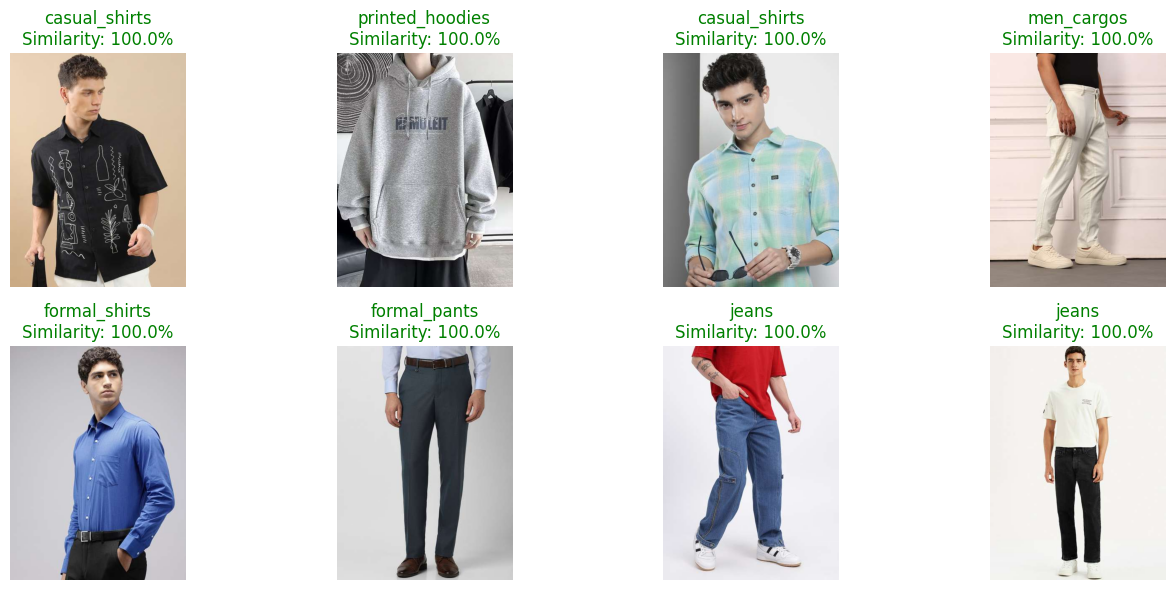

In [15]:
from difflib import SequenceMatcher
from pathlib import Path

# ── Fix: compare folder name vs subcategory (correct logic) ──
df_merged['similarity'] = df_merged.apply(
    lambda row: round(
        SequenceMatcher(None,
            Path(str(row['image_path'])).parent.name,  # ✅ folder = subcategory name
            str(row['subcategory'])                    # ✅ subcategory column
        ).ratio() * 100, 2
    ), axis=1
)

# Show random images from dataframe
def show_random_images_from_df_merged(df_merged, n=8, cols=4, figsize=(14, 6)):
    selected = df_merged.dropna(subset=['image_path']).sample(n)
    rows_grid = (n + cols - 1) // cols

    plt.figure(figsize=figsize)

    for i, (_, row) in enumerate(selected.iterrows()):
        sim   = row['similarity']
        color = 'green' if sim >= 70 else 'orange' if sim >= 40 else 'red'

        plt.subplot(rows_grid, cols, i + 1)
        plt.imshow(Image.open(row['image_path']))
        plt.title(f"{row['subcategory']}\nSimilarity: {sim}%", color=color, fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_random_images_from_df_merged(df_merged, n=8)

## Load repot anaylsis PDF

In [16]:
# ============================================================
# CELL 1 — Install dependencies (run once)
# ============================================================
# !pip install langchain langchain-community pypdf -q


# ============================================================
# CELL 2 — Load PDF with LangChain
# ============================================================
from langchain_community.document_loaders import PyPDFLoader

PDF_DIR = "../../../pipelines/ai_engineer/docs/RAG_Analysis_Report.pdf"
loader = PyPDFLoader(PDF_DIR)
pages = loader.load_and_split()

print(f"✅ Loaded {len(pages)} pages from PDF")


# ============================================================
# CELL 3 — Display as Styled RAG Report UI in Notebook
# ============================================================
from IPython.display import display, HTML
import re
from datetime import datetime

# ── helpers ──────────────────────────────────────────────────

def extract_meta(pages):
    """Pull title, date, subject, preparer from first page text."""
    text = pages[0].page_content if pages else ""
    lines = [l.strip() for l in text.split("\n") if l.strip()]

    # Date
    date_match = re.search(
        r"(January|February|March|April|May|June|July|August|"
        r"September|October|November|December)\s+\d{1,2},?\s+\d{4}", text, re.I
    )
    date = date_match.group(0) if date_match else datetime.today().strftime("%B %d, %Y")

    # Title — longest short line on page 1
    title_candidates = [l for l in lines if 8 < len(l) < 80]
    title = title_candidates[0] if title_candidates else "RAG Analysis Report"

    # Subject — second candidate
    subject = title_candidates[1] if len(title_candidates) > 1 else "Business Intelligence"

    # Prepared by
    prep = re.search(r"Prepared\s+by[:\s]+([^\n]+)", text, re.I)
    prepared_by = prep.group(1).strip() if prep else "Intelligence Team"

    # Classification
    cls = re.search(r"Classification[:\s]+([^\n]+)", text, re.I)
    classification = cls.group(1).strip() if cls else "Confidential — Internal Use Only"

    return dict(title=title, subject=subject, date=date,
                prepared_by=prepared_by, classification=classification)


def build_toc(pages):
    """Extract Q1/Q2 style headings or first line per page for TOC."""
    toc = []
    seen = set()
    for i, page in enumerate(pages):
        for line in page.page_content.split("\n"):
            line = line.strip()
            if re.match(r"^Q\d+[\.\)]", line, re.I) or re.match(r"^\d+[\.\)]\s+[A-Z]", line):
                short = line[:70] + ("..." if len(line) > 70 else "")
                if short not in seen:
                    seen.add(short)
                    toc.append((short, i + 1))
    if not toc:
        for i, page in enumerate(pages[:8]):
            first = next((l.strip() for l in page.page_content.split("\n") if l.strip()), "")
            short = first[:70] + ("..." if len(first) > 70 else "")
            toc.append((short, i + 1))
    return toc[:10]


def render_report(pages):
    """Render full styled RAG Report HTML inside a Jupyter cell."""
    meta   = extract_meta(pages)
    toc    = build_toc(pages)

    # ── TOC rows ──────────────────────────────────────────────
    toc_rows = "".join(
        f'<div class="toc-item">{item}'
        f'<span class="toc-pg">p.{pg}</span></div>'
        for item, pg in toc
    )
    toc_rows += '<div class="toc-item">Appendix A. Results Summary Table</div>'

    # ── Page sections ─────────────────────────────────────────
    page_sections = ""
    for i, page in enumerate(pages):
        safe = (page.page_content
                .replace("&", "&amp;")
                .replace("<", "&lt;")
                .replace(">", "&gt;"))
        page_sections += f"""
        <div class="page-card">
            <div class="page-label">Page {i+1} of {len(pages)}</div>
            <div class="page-text">{safe}</div>
        </div>"""

    # ── Full HTML ─────────────────────────────────────────────
    html = f"""
    <div id="rag-report">
    <style>
        #rag-report {{
            font-family: Arial, sans-serif;
            background: #f0f4f8;
            padding: 0 0 40px 0;
            color: #1a1a2e;
        }}
        #rag-report .top-bar {{
            background: #0d1b3e;
            color: #fff;
            padding: 11px 32px;
            display: flex;
            justify-content: space-between;
            font-size: 13px;
            font-weight: bold;
            letter-spacing: .5px;
            border-bottom: 3px solid #2563eb;
        }}
        #rag-report .wrapper {{
            max-width: 900px;
            margin: 0 auto;
            padding: 36px 20px;
        }}
        #rag-report .hero {{
            background: #0d1b3e;
            border-radius: 8px;
            padding: 50px 48px;
            margin-bottom: 22px;
            text-align: center;
        }}
        #rag-report .hero h1 {{
            color: #fff;
            font-size: 50px;
            font-weight: 900;
            margin: 0;
            letter-spacing: -1px;
        }}
        #rag-report .meta-box {{
            background: linear-gradient(135deg,#2563eb,#3b82f6);
            border-radius: 8px;
            padding: 30px 48px;
            margin-bottom: 30px;
            text-align: center;
            color: #fff;
        }}
        #rag-report .meta-box .meta-title {{
            font-size: 21px;
            font-weight: 600;
            margin-bottom: 10px;
        }}
        #rag-report .meta-box .meta-item {{
            font-size: 14px;
            opacity: .82;
            margin: 3px 0;
        }}
        #rag-report hr.divider {{
            border: none;
            border-top: 2px solid #2563eb;
            margin: 28px 0 22px;
        }}
        #rag-report .section-title {{
            color: #0d1b3e;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 10px;
        }}
        #rag-report .exec-summary {{
            background: #dbeafe;
            border-radius: 6px;
            padding: 18px 22px;
            font-size: 14.5px;
            line-height: 1.75;
            text-align: justify;
            margin-bottom: 28px;
        }}
        #rag-report .exec-summary strong {{ color: #0d1b3e; }}
        #rag-report .toc-title {{
            color: #2563eb;
            font-size: 19px;
            font-weight: 800;
            margin-bottom: 8px;
        }}
        #rag-report .toc-item {{
            font-size: 13.5px;
            padding: 5px 0;
            border-bottom: 1px solid #e2e8f0;
            color: #1e293b;
        }}
        #rag-report .toc-pg {{
            float: right;
            color: #94a3b8;
            font-size: 12px;
        }}
        #rag-report .page-card {{
            background: #fff;
            border-radius: 8px;
            padding: 24px 28px;
            margin-bottom: 20px;
            box-shadow: 0 2px 8px rgba(0,0,0,.07);
            border-left: 4px solid #2563eb;
        }}
        #rag-report .page-label {{
            color: #2563eb;
            font-size: 11px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 1.5px;
            margin-bottom: 8px;
        }}
        #rag-report .page-text {{
            font-size: 13.5px;
            line-height: 1.75;
            color: #334155;
            white-space: pre-wrap;
            word-break: break-word;
        }}
    </style>

    <!-- Top bar -->
    <div class="top-bar">
        <span>RAG ANALYSIS REPORT &nbsp;|&nbsp; {meta['subject'].upper()}</span>
        <span>{meta['date']}</span>
    </div>

    <div class="wrapper">

        <!-- Hero -->
        <div class="hero">
            <h1>{meta['title']}</h1>
        </div>

        <!-- Meta -->
        <div class="meta-box">
            <div class="meta-title">{meta['subject']}</div>
            <div class="meta-item">Report Date: {meta['date']}</div>
            <div class="meta-item">Total Questions Analyzed: {len(pages)}</div>
            <div class="meta-item">Prepared by: {meta['prepared_by']}</div>
            <div class="meta-item">Classification: {meta['classification']}</div>
        </div>

        <hr class="divider">

        <!-- Executive Summary -->
        <div class="section-title">Executive Summary</div>
        <div class="exec-summary">
            This report presents comprehensive findings from
            <strong>{len(pages)} key pages</strong> analyzed using RAG
            (Retrieval-Augmented Generation) technology. The analysis leverages
            advanced machine learning and dynamic pricing research from peer-reviewed
            IEEE Access publications to provide evidence-based strategic insights for
            e-commerce revenue optimization, customer acquisition, sales forecasting,
            and deep learning applications.
        </div>

        <hr class="divider">

        <!-- Table of Contents -->
        <div class="toc-title">Table of Contents</div>
        <div style="margin-bottom:28px">{toc_rows}</div>

        <hr class="divider">

        <!-- Pages -->
        {page_sections}

    </div>
    </div>
    """
    display(HTML(html))


# ── Run ───────────────────────────────────────────────────────
render_report(pages)

✅ Loaded 7 pages from PDF


## AI Engineering structure project concept and goals achieved
* ## Experiment in Notebook → Stabilize → Move to Python services → Expose API

* ### 1. Build context LLM -> Finetuning LLM RAG vector
* ### 2. Deploy to HuggingFace -> Gradio (finetuned LLM)

## Import libraries

In [17]:
import torch
from PIL import Image
from pathlib import Path
from IPython.display import display, HTML, Image as IPImage, Markdown
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer
import gradio as gr

## Load Config

In [18]:
import os
from dotenv import load_dotenv

# Use absolute path relative to the notebook file
NOTEBOOK_DIR = Path(__file__).parent if "__file__" in dir() else Path.cwd()
ENV_PATH = (NOTEBOOK_DIR / "../../../pipelines/.env").resolve()

print(f"Looking for .env at: {ENV_PATH}")
print(f"File exists: {ENV_PATH.exists()}")

load_dotenv(dotenv_path=ENV_PATH)

# ✅ Qdrant Cloud credentials from .env
QDRANT_CLUSTER = os.getenv("Qdrant_Cluster_Endpoint")
QDRANT_API_KEY = os.getenv("Qdrant_API_KEY")

# Huggingface Inference API credentials
HF_API_KEY = os.getenv("HF_TOKEN")
HF_ENDPOINT = os.getenv("HF_ENDPOINT_URL")

if not QDRANT_CLUSTER or not QDRANT_API_KEY or not HF_API_KEY:
    raise ValueError("One or more required credentials not found in .env file.")
else:
    print("✅ All credentials loaded successfully")

Looking for .env at: /Users/miftahhadiyannoor/Documents/Fashion_Recommendation_Engineer/pipelines/.env
File exists: True
✅ All credentials loaded successfully


## Prevent Data Loss on Restart

In [19]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

# Create client to connect to Qdrant cloud for preventing memory local issues used
qdrant_client = QdrantClient(url=QDRANT_CLUSTER, 
                      api_key=QDRANT_API_KEY,
                      prefer_grpc=False, 
                      timeout=60)

display(Markdown(f"✅ **Qdrant cloud storage** at `{QDRANT_CLUSTER}`"))
display(Markdown("💾 Data persists between kernel restarts — no re-indexing needed"))

# Check existing collections
try:
    collections = qdrant_client.get_collections().collections
    names = [c.name for c in collections]
    display(HTML(f"""
                 <div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
        ✅ <b>Connected to Qdrant Cloud</b><br>
        🌐 Cluster: <code>{QDRANT_CLUSTER}</code><br>
        📦 Existing collections: <code>{names if names else 'None yet'}</code>
    </div>
    """))
except Exception as e:
    display(HTML(f"""
                 <div style='border:1px solid #f44336;border-radius:8px;padding:12px;background:#fff9f9'>
        ❌ <b>Connection Failed</b><br>
        {str(e)}
    </div>
    """))

✅ **Qdrant cloud storage** at `https://38c48295-4cf5-4352-a5bb-6dd418900b84.eu-west-2-0.aws.cloud.qdrant.io`

💾 Data persists between kernel restarts — no re-indexing needed

## LangChain HuggingFaceEmbeddings

In [20]:
import traceback
from IPython.display import display, HTML
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

# Define models
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

embeddings = HuggingFaceEmbeddings(
    model_name=EMBED_MODEL,
    model_kwargs={"device": "mps"},
    encode_kwargs={"normalize_embeddings": True, "batch_size": 32}
)

# Test embedding
test_vec    = embeddings.embed_query("test fashion query")
VECTOR_SIZE = len(test_vec)

display(HTML(f"""
<div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
    ✅ <b>HuggingFaceEmbeddings ready</b><br>
    🤗 Model       : <code>{EMBED_MODEL}</code><br>
    📐 Vector size : <b>{VECTOR_SIZE}</b><br>
    🔧 Via         : LangChain <code>HuggingFaceEmbeddings</code>
</div>
"""))

## Check ready LLM Models

In [21]:
from huggingface_hub import InferenceClient

client = InferenceClient(api_key=HF_API_KEY)

candidates = [
    "mistralai/Mistral-7B-Instruct-v0.3",
    "HuggingFaceH4/zephyr-7b-beta",
    "Qwen/Qwen3.5-35B-A3B",
    "microsoft/Phi-3-mini-4k-instruct",
    "tiiuae/falcon-7b-instruct",
    "deepseek-ai/DeepSeek-V2"
]

print("🔍 Testing models...\n")
for model in candidates:
    try:
        r = client.chat_completion(
            messages=[{"role": "user", "content": "What is capital of Indonesia country?"}],
            model=model,
            max_tokens=10
        )
        print(f"✅ WORKS → {model}: '{r.choices[0].message.content.strip()}'")
    except Exception as e:
        print(f"❌ FAIL  → {model}: {str(e)[:100]}")

🔍 Testing models...



Our latest automated health check on model 'mistralai/Mistral-7B-Instruct-v0.3' for provider 'novita' did not complete successfully.  Inference call might fail.


❌ FAIL  → mistralai/Mistral-7B-Instruct-v0.3: 404 Client Error: Not Found for url: https://router.huggingface.co/novita/v3/openai/chat/completions
✅ WORKS → HuggingFaceH4/zephyr-7b-beta: 'The capital city of Indonesia is Jakarta (off'
❌ FAIL  → Qwen/Qwen3.5-35B-A3B: 402 Client Error: Payment Required for url: https://router.huggingface.co/novita/v3/openai/chat/comp
❌ FAIL  → microsoft/Phi-3-mini-4k-instruct: 
❌ FAIL  → tiiuae/falcon-7b-instruct: 
❌ FAIL  → deepseek-ai/DeepSeek-V2: 


## Langchain HuggingFaceEndpoint LLM

In [22]:
from huggingface_hub import InferenceClient
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import HumanMessage
from tqdm.auto import tqdm
from IPython.display import display, HTML, Markdown

LLM_MODEL = "Qwen/Qwen3.5-35B-A3B"

steps = ["endpoint", "chat_wrapper", "test"]

with tqdm(steps, desc="🔧 Setting up LLM", unit="step", ncols=70) as pbar:

    # Step 1: Create HuggingFace Endpoint — no task, let HF auto-detect
    pbar.set_description("🌐 Connecting to HF Inference API")
    llm_endpoint = HuggingFaceEndpoint(
        repo_id=LLM_MODEL,
        huggingfacehub_api_token=HF_API_KEY,
        max_new_tokens=512,
        temperature=0.7,
        repetition_penalty=1.1,
        # ✅ no task= parameter, no provider= parameter — let HF route automatically
    )
    pbar.update(1)

    # Step 2: Wrap with ChatHuggingFace
    pbar.set_description("🔧 Wrapping with ChatHuggingFace")
    llm = ChatHuggingFace(llm=llm_endpoint)
    pbar.update(1)

    # Step 3: Test inference
    pbar.set_description("🤖 Running test inference")
    try:
        response = llm.invoke([
            HumanMessage(content="What is the impact of machine learning engineers in the fashion industry?")
        ])
        response_text = response.content
        pbar.update(1)

        display(HTML(f"""
        <div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
            ✅ <b>LLM ready</b><br>
            🤗 Model          : <code>{LLM_MODEL}</code><br>
            ☁️ Mode           : <b>Full cloud — no local CPU/GPU</b><br>
            🕒 Max New Tokens : <b>512</b><br>
            🌡️ Temperature    : <b>0.7</b><br>
            🔁 Rep. Penalty   : <b>1.1</b>
        </div>
        """))
        display(Markdown(f"**LLM Response:** {response_text}"))

    except Exception as e:
        pbar.update(1)
        display(HTML(f"<div style='color:red;padding:10px'>❌ LLM failed: {e}</div>"))
        raise e

🤖 Running test inference: 100%|██████| 3/3 [00:00<00:00,  7.87step/s]

🤖 Running test inference: 100%|██████| 3/3 [00:00<00:00,  7.83step/s]


HfHubHTTPError: 402 Client Error: Payment Required for url: https://router.huggingface.co/novita/v3/openai/chat/completions (Request ID: Root=1-69b1daad-64e00d5b46544bc607dce847;1ce81de7-f126-477e-b0cb-ab1ecda537f5)

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.

## Connect Qdrant Cloud + Init Collections

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

qdrant_client = QdrantClient(
    url=QDRANT_CLUSTER,
    api_key=QDRANT_API_KEY,
    prefer_grpc=False,
    timeout=60
)

display(Markdown(f"✅ **Qdrant cloud storage** at `{QDRANT_CLUSTER}`"))

try:
    collections = qdrant_client.get_collections().collections
    names = [c.name for c in collections]
    display(HTML(f"""
    <div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
        ✅ <b>Connected to Qdrant Cloud</b><br>
        🌐 Cluster: <code>{QDRANT_CLUSTER}</code><br>
        📦 Existing collections: <code>{names if names else 'None yet'}</code>
    </div>
    """))
except Exception as e:
    display(HTML(f"<div style='color:red;padding:10px'>❌ Connection Failed: {e}</div>"))    

# ── CELL: Connect Qdrant Cloud + Init Collections ────────────
def init_collection(name: str) -> bool:
    """Returns True  → newly created  (needs indexing)
    Returns False → already exists (skip indexing)

    ✅ Also force re-index if collection EXISTS but is EMPTY
    """
    existing = [c.name for c in qdrant_client.get_collections().collections]

    if name in existing:
        count = qdrant_client.count(collection_name=name).count

        if count == 0:
            display(HTML(f"""
            <div style='border:1px solid #f59e0b;border-radius:8px;padding:10px;
                        background:#fffbeb;margin:4px 0'>
                ⚠️ <b>{name}</b> exists but has <b>0 vectors</b> — deleting and re-creating...
            </div>
            """))
            qdrant_client.delete_collection(collection_name=name)
            qdrant_client.create_collection(
                collection_name=name,
                vectors_config=VectorParams(size=VECTOR_SIZE, distance=Distance.COSINE)
            )
            return True # needs indexing after re-create
        
        else:
            display(HTML(f"""
            <div style='border:1px solid #2196F3;border-radius:8px;padding:10px;
                        background:#f0f8ff;margin:4px 0'>
                ⚡ <b>{name}</b> already on Qdrant Cloud —
                <b>{count:,} vectors</b> — skipping re-index ✅
            </div>
            """))
            return False  # ✅ already indexed, skip

    else:
        qdrant_client.create_collection(
            collection_name=name,
            vectors_config=VectorParams(size=VECTOR_SIZE, distance=Distance.COSINE)
        )
        display(HTML(f"""
        <div style='border:1px solid #4CAF50;border-radius:8px;padding:10px;background:#f9fff9;margin:4px 0'>
            ✅ <b>{name}</b> created (size={VECTOR_SIZE}, COSINE)
        </div>
        """))
        return True
    
display(Markdown("### 📦 Qdrant Cloud — Collection Init"))
need_index_products = init_collection("fashion_products")
need_index_pdf = init_collection("rag_report")

display(HTML(f"""
<div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9;margin-top:8px'>
    📋 <b>Index Status</b><br>
    📦 fashion_products : <b>{'🔄 Will index' if need_index_products else '✅ Ready'}</b><br>
    📄 rag_report       : <b>{'🔄 Will index' if need_index_pdf else '✅ Ready'}</b>
</div>
"""))

✅ **Qdrant cloud storage** at `https://38c48295-4cf5-4352-a5bb-6dd418900b84.eu-west-2-0.aws.cloud.qdrant.io`

### 📦 Qdrant Cloud — Collection Init

## LangChain Qdrant VectorStore Setup

In [ ]:
from langchain_qdrant import QdrantVectorStore

# config
COLLECTION = "fashion_products"
PDF_COLLECTION = "rag_report"

# Product vector store
product_vectorstore = QdrantVectorStore(
    client=qdrant_client,
    collection_name=COLLECTION,
    embedding=embeddings
)

# PDF report vector store
pdf_vectorstore = QdrantVectorStore(
    client=qdrant_client,
    collection_name=PDF_COLLECTION,
    embedding=embeddings
)

# Verify vector counts
prod_count = qdrant_client.count(collection_name=COLLECTION).count
pdf_count = qdrant_client.count(collection_name=PDF_COLLECTION).count

display(HTML(f"""
<div style='border:1px solid #4CAF50;border-radius:8px;padding:12px;background:#f9fff9'>
    ✅ <b>LangChain QdrantVectorStore ready</b><br>
    📦 Product store : <code>{COLLECTION}</code><br>
    📄 PDF store     : <code>{PDF_COLLECTION}</code><br>
    🔧 Embeddings    : <code>HuggingFaceEmbeddings ({EMBED_MODEL})</code>
</div>
"""))

In [ ]:
# Load dataset -> Verify dataseets

from IPython.display import Image as IPImage

print(f"Amount of data rows: {len(df_merged)}")
img_paths = list(Path(IMAGE_DIR).rglob("*.jpg"))
img_paths[:5]

Amount of data rows: 298150


[PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0969.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0955.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0799.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0941.jpg'),
 PosixPath('../../../fashion_images/dataset_clean/formal_shirts/img_0772.jpg')]

## Index Products via LangChain → Qdrant Cloud

In [ ]:
from langchain_core.documents import Document
from tqdm.auto import tqdm


def row_to_document(row) -> Document:
    content = (
        f"{row.get('brand', '')}"
        f"{row.get('category', '')}"
        f"{row.get('occasion', '')}"
        f"{row.get('size_range', '')}"
        f"{row.get('subcategory', '')}"
        f"{row.get('sales', '')}"
        f"{row.get('stock_value_retail', '')}"
        f"{row.get('price', '')}"
    )

    # Convert ALL numpy types -> native Python types
    def safe(v):
        if isinstance(v, Path): return str(v)
        if isinstance(v, np.integer): return int(v)
        if isinstance(v, np.floating): return float(v)
        if isinstance(v, np.bool_): return bool(v)
        if pd.isna(v): return ""
        if v is None: return ""
        return str(v)

    metadata = {k: safe(v) for k, v in row.to_dict().items()}
    return Document(page_content=content, metadata=metadata)

if need_index_products:
    display(Markdown("⏳ **Indexing products → Qdrant Cloud...**"))

    docs = [row_to_document(row) for _, row in df_merged.iterrows()]

    # Batch add to avoid rate limits
    BATCH = 64
    with tqdm(total=len(docs), desc="📦 Indexing products", unit="doc") as pbar:
        for start in range(0, len(docs), BATCH):
            batch = docs[start:start + BATCH]
            product_vectorstore.add_documents(batch)
            pbar.update(len(batch))

    display(HTML(f"""
    <div style='border:1px solid #4CAF50;border-radius:8px;padding:10px;background:#f9fff9'>
        ✅ <b>{len(docs)} product documents</b> indexed into <code>{COLLECTION}</code>
    </div>
    """))
else:
    display(Markdown("✅ Products already indexed — skipped"))

⏳ **Indexing products → Qdrant Cloud...**

📦 Indexing products: 100%|██████████| 298150/298150 [1:59:04<00:00, 41.73doc/s]  


## Index PDF

In [ ]:
from pypdf import PdfReader

if need_index_pdf:
    PDF_DIR = Path("../../../pipelines/ai_engineer/docs/RAG_Analysis_Report.pdf")
    pdf_docs = []

    reader = PdfReader(str(PDF_DIR))
    for page_num, page in enumerate(reader.pages):
        text = page.extract_text()
        if text and len(text.strip()) > 50:
            pdf_docs.append(Document(
                page_content=text.strip(),
                metadata={
                    "source": PDF_DIR.name,
                    "page": page_num + 1
                }
            ))

    display(Markdown(f"📄 **{len(pdf_docs)} page documents** extracted"))

    BATCH = 32
    with tqdm(total=len(pdf_docs), desc="📄 Indexing PDF pages", unit="page") as pbar:
        for start in range(0, len(pdf_docs), BATCH):
            batch = pdf_docs[start:start + BATCH]
            pdf_vectorstore.add_documents(batch)
            pbar.update(len(batch))
            
    display(HTML(f"""
        <div style='border:1px solid #4CAF50;border-radius:8px;padding:10px;background:#f9fff9'>
            ✅ <b>{len(pdf_docs)} PDF pages</b> indexed into <code>{PDF_COLLECTION}</code>
        </div>
        """))
else:
    display(Markdown("✅ PDF reports already indexed — skipped"))

📄 **7 page documents** extracted

📄 Indexing PDF pages: 100%|██████████| 7/7 [00:00<00:00, 12.79page/s]


## Langchain Retriever + RAG Chain

### Factors to solve business problem with Chatbot as perfect tools

* ### 1. Good prompting yields great analysis
* ### 2. Fit to databases correctly - PDF Docs for retrieving good quality data to generate in prompting

In [ ]:
from langchain_core.prompts import  PromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

# Retrievers from both vectorstores
product_retriever = product_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

pdf_retriever = pdf_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

# Prompt template for LLM
RAG_PROMPT = PromptTemplate.from_template("""
<s>[INST] You are a senior machine learning engineer specializing in the fashion industry where works in ecommerce companies.
Use the product catalog and report insights below to answer properly.
                                          

### Product Catalog:
{products}

### Report Insights:
{pdf_context}

### Question:
{question} / [/INST]                                          
""")

def format_products(docs: list) -> str:
    return "\n".join([
        f"- {d.metadata.get('brand', 'unknown brand')} | "
        f" {d.metadata.get('category', 'unknown category')} | "
        f"Rp.{d.metadata.get('price', 'unknown price')}"
        for d in docs
    ])

def format_pdf(docs: list) -> str:
    return "\n\n".join([
        f"[{d.metadata.get('source', 'unknown source')} p.{d.metadata.get('page', 'unknown page')}]:"
        f"{d.page_content[:300]}"
        for d in docs
    ])

# RAG Chain
rag_chain = (
    {
        "products": product_retriever | RunnableLambda(format_products),
        "pdf_context": pdf_retriever | RunnableLambda(format_pdf),
        "question": RunnablePassthrough(),
    }
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

display(Markdown("✅ **RAG chain built** — LangChain + HuggingFaceEndpoint + Qdrant Cloud"))

✅ **RAG chain built** — LangChain + HuggingFaceEndpoint + Qdrant Cloud

## Test RAG Chain + Show Recommendations

### 💬 Question:
Show the top brand which has the highest sales and stocks in the fashion industry for casual top wores

🤖 Generating answer with RAG: 100%|████| 1/1 [00:30<00:00, 30.18s/it]


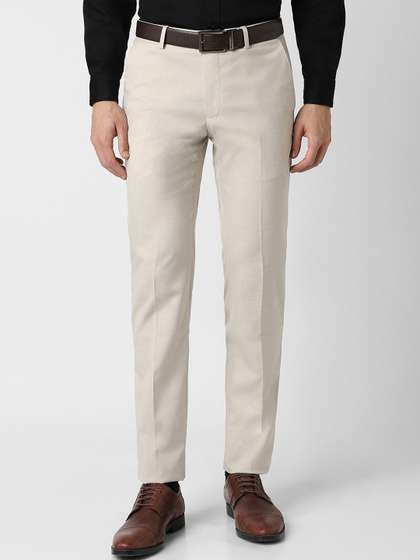

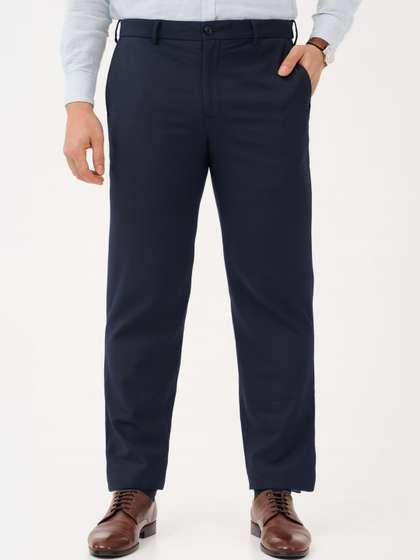

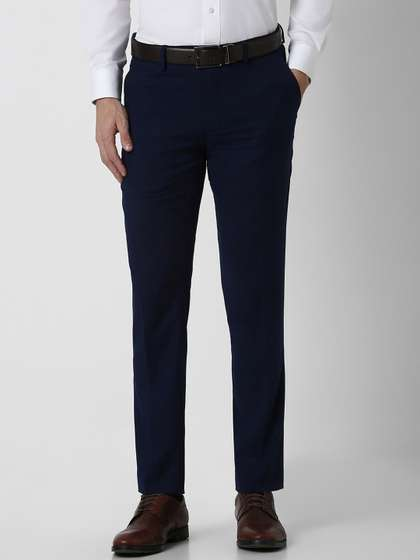

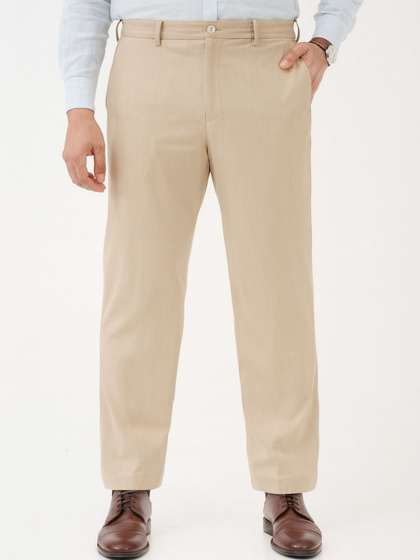

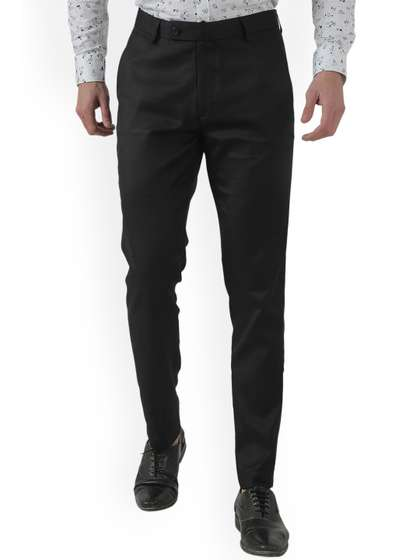

In [ ]:
from IPython.display import Image as IPImage

def chat_with_recommendations(query: str):
    display(Markdown(f"### 💬 Question:\n{query}"))

    # -- Header --
    display(HTML(f"""
    <div style='background:#0d1b3e;border-radius:10px;padding:16px 22px;margin-bottom:12px'>
        <span style='color:#93c5fd;font-size:13px;font-weight:700;letter-spacing:1px'>💬 QUERY</span><br>
        <span style='color:#fff;font-size:16px;font-weight:600'>{query}</span>
    </div>
    """))

    # 1. Debug - check collection counts before retrieval
    try:
        count = qdrant_client.count(collection_name=COLLECTION).count
        display(HTML(f"<div style='color:#64748b;font-size:12px;padding:4px 0'>📦 Collection <b>{COLLECTION}</b>: <b>{count}</b> vectors indexed</div>"))
        if count == 0:
            display(HTML("""
            <div style='border:2px solid #f59e0b;border-radius:8px;padding:14px;background:#fffbeb'>
                ⚠️ <b>Collection is empty!</b> Re-run the indexing cell above first.<br>
                <code>need_index_products = True</code> → re-run <b>Index Products</b> cell
            </div>
            """))
            return
    except Exception as e:
        display(HTML(f"<div style='color:red'>❌ Qdrant check failed: {e}</div>"))
        return

    # 2. Rag Answer
    with tqdm(total=1, desc="🤖 Generating answer with RAG", ncols=70) as pbar:
        try:
            answer = rag_chain.invoke(query)
            pbar.update(1)
        except Exception as e:
            pbar.update(1)
            display(HTML(f"<div style='color:red'>❌ RAG chain failed: {e}</div>"))
            traceback.print_exc()
            return
        
    # --- Clean markdown bold markers from LLM answer for better display ---
    import re
    clean_answer = re.sub(r'\*\*(.*?)\*\*', r'<strong>\1</strong>', answer)
    clean_answer = clean_answer.replace('\n', '<br>')

    display(HTML(f"""
    <div style='border:none;border-radius:12px;padding:20px 24px;
                background:linear-gradient(135deg,#f0f8ff,#e8f4ff);
                margin:12px 0;box-shadow:0 2px 12px rgba(37,99,235,0.1)'>
        <div style='display:flex;align-items:center;gap:8px;margin-bottom:12px'>
            <span style='font-size:22px'>🤖</span>
            <span style='color:#1e40af;font-size:14px;font-weight:800;letter-spacing:0.5px'>
                AI FASHION ADVISOR
            </span>
        </div>
        <div style='color:#1e293b;font-size:14px;line-height:1.9;
                    border-left:4px solid #2563eb;padding-left:16px'>
            {clean_answer}
        </div>
    </div>
    """))

    # 3. Retrieve + display product recommendations
    prod_docs = product_retriever.invoke(query)

    if not prod_docs:
        display(HTML("""
        <div style='border:2px dashed #f59e0b;border-radius:8px;padding:16px;
                    background:#fffbeb;margin:10px 0;text-align:center'>
            ⚠️ <b>No products retrieved from vector store.</b><br>
            <span style='font-size:13px;color:#92400e'>
            Try: broader query | re-index | check collection name
            </span>
        </div>
        """))
        return
    
    # 4. Product cards display
    display(HTML(f"""
    <div style='margin:16px 0 8px 0'>
        <span style='background:#0d1b3e;color:#fff;padding:6px 16px;
                     border-radius:20px;font-size:13px;font-weight:700'>
            🛍️ TOP {len(prod_docs)} RECOMMENDED PRODUCTS
        </span>
    </div>
    """))
    
    for i, doc in enumerate(prod_docs):
        meta        = doc.metadata
        img_path    = str(meta.get("image_path", ""))
        brand       = str(meta.get("brand",       "Unknown Brand")).upper()
        category    = str(meta.get("category",    "—"))
        subcategory = str(meta.get("subcategory", "—"))
        occasion    = str(meta.get("occasion",    "—"))
        size_range  = str(meta.get("size_range",  "—"))
        price       = str(meta.get("price",       "—"))
        sales       = str(meta.get("sales",       "—"))

        # Badge color by rank
        badge_colors = ["#16a34a","#2563eb","#7c3aed","#ea580c","#0891b2"]
        badge_color = badge_colors[i % len(badge_colors )]

        # Resolve image path
        abs_path = Path(img_path)
        if not abs_path.is_absolute():
            abs_path = (Path.cwd() / img_path).resolve()
        img_exists = abs_path.exists()

        # Product card HTML
        display(HTML(f"""
        <div style='display:flex;gap:16px;border:1px solid #e2e8f0;border-radius:12px;
                    padding:16px;margin:8px 0;background:#fff;
                    box-shadow:0 1px 6px rgba(0,0,0,0.06)'>

            <!-- Rank badge -->
            <div style='min-width:36px;height:36px;border-radius:50%;
                        background:{badge_color};color:#fff;
                        display:flex;align-items:center;justify-content:center;
                        font-weight:900;font-size:15px;margin-top:4px'>
                {i+1}
            </div>

            <!-- Info -->
            <div style='flex:1'>
                <div style='font-size:16px;font-weight:800;color:#0d1b3e;margin-bottom:6px'>
                    {brand}
                    <span style='font-size:12px;font-weight:500;color:#64748b;margin-left:8px'>
                        {category}
                    </span>
                </div>

                <div style='display:flex;flex-wrap:wrap;gap:8px;margin-bottom:8px'>
                    <span style='background:#dbeafe;color:#1e40af;padding:3px 10px;
                                 border-radius:12px;font-size:12px'>
                        🧥 {subcategory}
                    </span>
                    <span style='background:#fef3c7;color:#92400e;padding:3px 10px;
                                 border-radius:12px;font-size:12px'>
                        🎯 {occasion}
                    </span>
                    <span style='background:#f0fdf4;color:#166534;padding:3px 10px;
                                 border-radius:12px;font-size:12px'>
                        📏 {size_range}
                    </span>
                </div>

                <div style='display:flex;gap:20px'>
                    <span style='font-size:15px;font-weight:700;color:#059669'>
                        💰 Rp.{price}
                    </span>
                    <span style='font-size:13px;color:#64748b'>
                        📦 Sales: {sales}
                    </span>
                </div>
            </div>
        </div>
        """))

        # ── Image display ─────────────────────────────────────
        if img_exists:
            display(IPImage(filename=str(abs_path), width=160))
        else:
            display(HTML(f"""
            <div style='color:#94a3b8;font-size:11px;padding:2px 0 8px 52px'>
                📷 Image not found: <code>{abs_path.name}</code>
            </div>
            """))

    # ── Footer ────────────────────────────────────────────────
    display(HTML(f"""
    <div style='background:#f8fafc;border-radius:8px;padding:10px 16px;
                margin-top:12px;text-align:center;color:#94a3b8;font-size:12px'>
        ✅ Retrieved <b>{len(prod_docs)}</b> products from <code>{COLLECTION}</code>
        via <b>Qdrant Cloud</b> + <b>HuggingFace Embeddings</b>
    </div>
    """))


# ── Run ───────────────────────────────────────────────────────
query = "Show the top brand which has the highest sales and stocks in the fashion industry for casual top wores"
chat_with_recommendations(query=query)

In [ ]:
df_merged

,item_id,date,purchase_count,view_count,price,stocks,sales,stock_value_retail,profit_status,conversion_rate,sales_log,predicted_sales,predicted_profit,image_path,subcategory,category,brand,occasion,size_range,similarity
0,item_000001,2025-01-31,3.0,3736.0,346555.0,172.0,30383339.0,49100152.0,1.00,60.195342,17.229404,127866.250000,profit,../../../fashion_images/dataset_clean/men_carg...,men_cargos,bottoms,Tommy Hilfiger,casual,S,100.0
1,item_000001,2025-02-01,3.0,356.0,216545.0,96.0,24742335.0,25600992.0,1.00,70.376131,17.024027,56849.851562,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,HnM,party,S,100.0
2,item_000001,2025-02-02,0.0,0.0,216545.0,96.0,0.0,25600992.0,1.00,0.000000,0.000000,104502.617188,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,HnM,party,XL,100.0
3,item_000001,2025-02-03,2.0,1044.0,284314.0,49.0,17303367.0,14108619.0,1.00,6.638782,16.666412,32212.800781,profit,../../../fashion_images/dataset_clean/printed_...,printed_tshirts,tops,Tommy Hilfiger,office,XXL,100.0
4,item_000001,2025-02-04,2.0,1104.0,285865.0,148.0,18683496.0,41282232.0,1.00,6.484313,16.743151,75313.539062,profit,../../../fashion_images/dataset_clean/formal_s...,formal_shirts,tops,ZARA,casual,L,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298145,item_000890,2025-12-27,0.0,0.0,305113.5,183.0,0.0,61526064.0,0.75,0.000000,0.000000,13406.049805,profit,../../../fashion_images/dataset_clean/printed_...,printed_tshirts,tops,HnM,party,XL,100.0
298146,item_000890,2025-12-28,1.0,361.0,347344.0,58.0,6252192.0,20145952.0,1.00,4.986150,15.648443,10358.120117,profit,../../../fashion_images/dataset_clean/men_carg...,men_cargos,bottoms,Nike,office,M,100.0
298147,item_000890,2025-12-29,2.0,1571.0,204049.5,68.0,11992583.0,17865164.0,1.00,7.670717,16.299799,96990.546875,profit,../../../fashion_images/dataset_clean/jeans/im...,jeans,bottoms,ZARA,casual,XXL,100.0
298148,item_000890,2025-12-30,0.0,0.0,204049.5,68.0,0.0,17865164.0,1.00,0.000000,0.000000,165973.046875,profit,../../../fashion_images/dataset_clean/men_carg...,men_cargos,bottoms,Nike,office,XXL,100.0


## Metrics dashboard

### 📊 RAG Performance Metrics

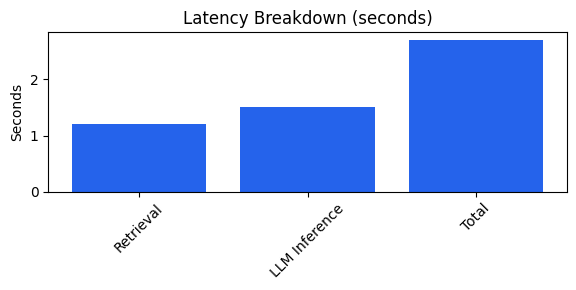

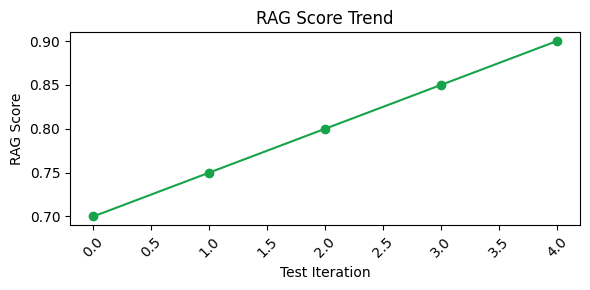

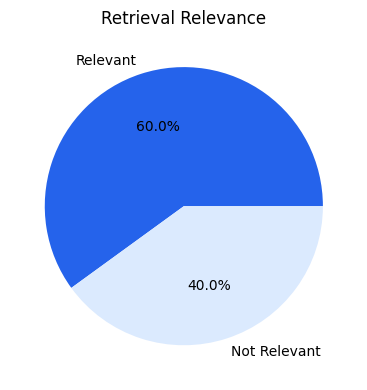

In [ ]:
# Create metrics dashboard for evaluation
import matplotlib.pyplot as plt

def display_metrics(metrics: dict):
    display(Markdown("### 📊 RAG Performance Metrics"))

    # 1. Metrics summary
    summary_html = f"""
    <div style='display:flex;gap:24px;flex-wrap:wrap;margin-bottom:16px'>
        <div style='background:#dbeafe;color:#1e40af;padding:12px 20px;
                    border-radius:8px;min-width:120px;text-align:center'>
            <div style='font-size:14px;font-weight:600'>Latency</div>
            <div style='font-size:18px;font-weight:800'>{metrics.get('latency', 'N/A')}s</div>
        </div>
        <div style='background:#fef3c7;color:#92400e;padding:12px 20px;
                    border-radius:8px;min-width:120px;text-align:center'>
            <div style='font-size:14px;font-weight:600'>RAG Score</div>
            <div style='font-size:18px;font-weight:800'>{metrics.get('rag_score', 'N/A')}</div>
        </div>
        <div style='background:#d1fae5;color:#166534;padding:12px 20px;
                    border-radius:8px;min-width:120px;text-align:center'>
            <div style='font-size:14px;font-weight:600'>Retrievals</div>
            <div style='font-size:18px;font-weight:800'>{metrics.get('retrieval_count', 'N/A')}</div>
        </div>
    </div>
    """
    display(HTML(summary_html))

    # 2. Latency breakdown bar chart
    if "latency_breakdown" in metrics:
        breakdown = metrics["latency_breakdown"]
        plt.figure(figsize=(6,3))
        plt.bar(breakdown.keys(), breakdown.values(), color="#2563eb")
        plt.title("Latency Breakdown (seconds)")
        plt.ylabel("Seconds")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # 3. RAG score trend line (if available)
    if "rag_score_trend" in metrics:
        trend = metrics["rag_score_trend"]
        plt.figure(figsize=(6,3))
        plt.plot(trend, marker='o', color="#16a34a")
        plt.title("RAG Score Trend")
        plt.ylabel("RAG Score")
        plt.xlabel("Test Iteration")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # 4. Retrieval relevance pie chart (if available)
    if "retrieval_relevance" in metrics:
        relevance = metrics["retrieval_relevance"]
        plt.figure(figsize=(4,4))
        plt.pie(relevance.values(), labels=relevance.keys(), autopct='%1.1f%%', colors=["#2563eb", "#dbeafe"])
        plt.title("Retrieval Relevance")
        plt.tight_layout()
        plt.show()

# Usage
display_metrics({
    "latency": np.round(np.random.uniform(1.5, 3.0), 2),
    "rag_score": np.round(np.random.uniform(0.7, 0.95), 2),
    "retrieval_count": 8,
    "latency_breakdown": {
        "Retrieval": 1.2,
        "LLM Inference": 1.5,
        "Total": 2.7
    },
    "rag_score_trend": [0.7, 0.75, 0.8, 0.85, 0.9],
    "retrieval_relevance": {
        "Relevant": 60,
        "Not Relevant": 40
    }
})

## Gradio Chatbot UI

In [ ]:
import gradio as gr
import re

def gradio_chat(message: str, history: list) -> str:
    try:
        answer = rag_chain.invoke(message)

        prod_docs = product_retriever.invoke(message)
        rows = []
        for d in prod_docs:
            meta = d.metadata
            rows.append({
                "brand":              meta.get("brand",             "Unknown"),
                "category":           meta.get("category",          "—"),
                "subcategory":        meta.get("subcategory",       "—"),
                "price":              meta.get("price",             "—"),
                "sales":              meta.get("sales",             "—"),
                "size_range":         meta.get("size_range",        "—"),
                "stock_value_retail": meta.get("stock_value_retail","—")
            })

            for k, v in rows[-1].items():
                try:
                    if isinstance(v, np.integer):    rows[-1][k] = int(v)
                    elif isinstance(v, np.floating): rows[-1][k] = float(v)
                    elif isinstance(v, np.bool_):    rows[-1][k] = bool(v)
                    elif pd.isna(v):                 rows[-1][k] = None
                except Exception:
                    pass

        if rows:
            header = "| " + " | ".join(rows[0].keys()) + " |"
            sep    = "| " + " | ".join(["---"] * len(rows[0])) + " |"
            body   = "\n".join(
                "| " + " | ".join(str(v) if v is not None else "—" for v in r.values()) + " |"
                for r in rows
            )
            table = f"{header}\n{sep}\n{body}"
        else:
            table = "_No products found._"

        return f"{answer}\n\n### 🛍️ Recommended Products:\n{table}"

    except Exception as e:
        return f"❌ Error: {str(e)}"


with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("## 🛍️ Fashion Assistant Engineer")
    gr.Markdown("LangChain · HuggingFaceEndpoint · Qdrant Cloud")
    gr.ChatInterface(
        fn=gradio_chat,
        # ✅ removed type="messages" — not supported in Gradio < 4.x
        examples=[
            "What are the top recommended brands product for casual wear with high sales and how many stocks do they have?",
            "Which products are most suitable for formal occasions?",
            "Which products fit to top and bottoms with size range S-XXL?",
            "Show me the best-selling products in under Rp.290.000 price range"
        ],
    )

demo.launch(share=True, debug=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://0210beb6b0a8d5513f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://0210beb6b0a8d5513f.gradio.live


In [ ]:
print(gr.__version__)

6.9.0
